In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bokeh.plotting import figure, show
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.io import output_notebook
output_notebook()

Loading BokehJS ...

In [4]:
df=pd.read_csv('techstore_chile_2024.csv')

In [13]:
#Con estos codigos vemos la informacion de la tabla cargada
print(df.shape())
print(df.info())
print(df.isnull().sum())

TypeError: 'tuple' object is not callable

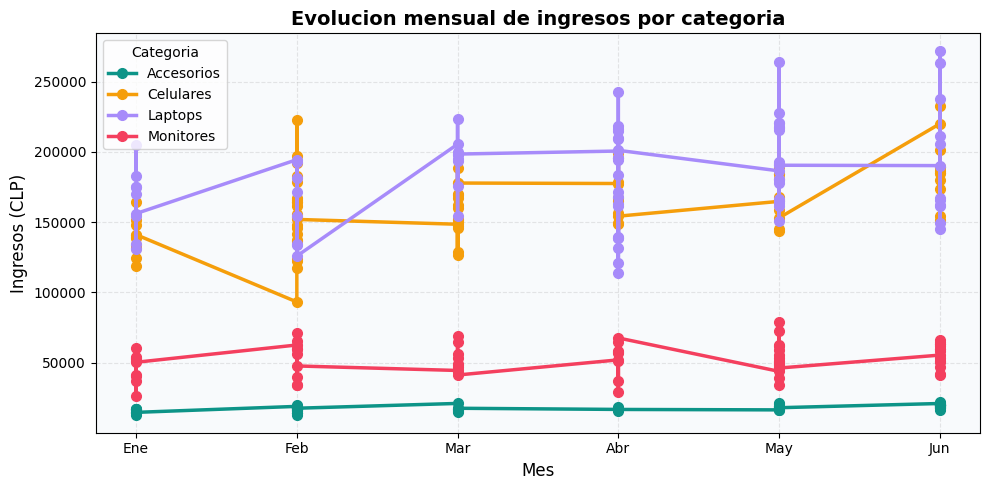

In [14]:
colores = ['#0D9488', '#F59E0B', '#A78BFA', '#F43F5E']
meses_label = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun']
fig, ax = plt.subplots(figsize=(10, 5))
for i, cat in enumerate(df['categoria'].unique()):
    subset = df[df['categoria'] == cat].sort_values('mes')
    ax.plot(subset['mes'], subset['ingresos'], 
            color=colores[i],
            linewidth=2.5, 
            marker='o', 
            markersize=7, 
            label=cat)
ax.set_title('Evolucion mensual de ingresos por categoria', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Ingresos (CLP)', fontsize=12)
ax.set_xticks(range(1, 7))
ax.set_xticklabels(meses_label)
ax.legend(title='Categoria', loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#F8FAFC')
plt.tight_layout()
plt.show()
#3)La categoria laptoo tiene mayor creciemiento
#4)set_xticks() define en que puntos  del eje se pondrán las marcas, y set_xticklabels() define qué texto,Si usas solo xticks, se veran numeros en lugar de nombres de meses
#5)permite que la cuadricula sea util. un alpha bajo hace que las lineas sean transparentes

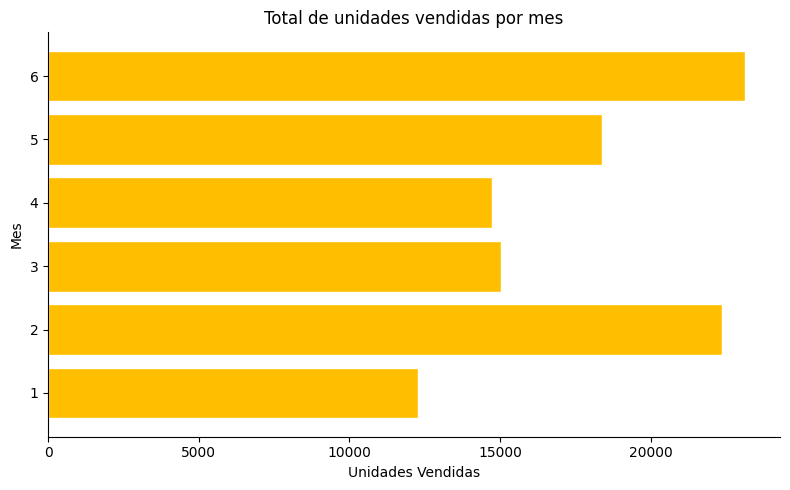

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
unidades_mes=df.groupby('mes')['unidades'].sum()
colores = []
for valor in unidades_mes.values:
    if valor > 1400:
        colores.append('#FFBF00')
    else:
        colores.append('#6BAED6')
ax.barh(unidades_mes.index, unidades_mes.values, color=colores, edgecolor='white')
ax.set_title('Total de unidades vendidas por mes')
ax.set_xlabel('Unidades Vendidas')
ax.set_ylabel('Mes')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
#diferencia entre las dos que una genera barras verticales y otras horizontales
#porque produce un eje mas limpio

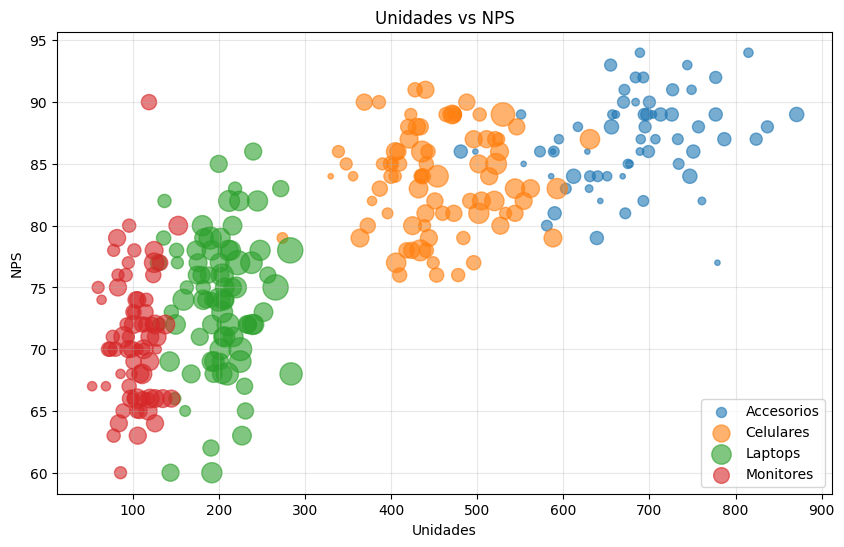

In [16]:
fig,ax=plt.subplots(figsize=(10,6))
cats=df['categoria'].unique()
cols=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
for i,c in enumerate(cats):
    d=df[df['categoria']==c]
    ax.scatter(d['unidades'],d['nps'],s=d['devueltos']*15,alpha=0.6,label=c,c=cols[i%len(cols)])
ax.set_title('Unidades vs NPS')
ax.set_xlabel('Unidades')
ax.set_ylabel('NPS')
ax.legend()
ax.grid(True,alpha=0.3)
plt.show()
#nol existe una relacion clara y el nps ya que los puntos estan dispersos.
#se usan para que los puntos sean mas visibles